# 5. Model Validation — Why These Models, and What Do They Test?

Two one-feature logistic regressions, used as **diagnostic checks**, not as
a ticket-routing model.

| Question | Row grain | Input | Binary outcome | A useful result would mean |
|---|---|---|---|---|
| Does collaboration identify commercial-plan concentration? | One customer | Maximum collaborators | Non-Free plan | Higher collaboration ranks non-Free customers above Free customers more often |
| Does current priority already recognise collaboration? | One ticket | Maximum collaborators | High/Critical priority | Higher collaboration ranks High/Critical tickets above Low/Medium tickets more often |

**Why logistic regression?** It translates collaborator count into the
probability of a binary outcome. The coefficient direction is readable, and
out-of-fold AUC tests ranking ability without choosing an arbitrary
probability threshold. AUC of 0.500 is no better than random ranking.

**Why not something more complex?**
- **K-means** has no outcome and would create clusters without answering
  either business question.
- **Random forest** adds opacity to a one-input relationship check without
  solving a richer prediction problem.
- **Churn modelling** is unsupported — no churn label exists.
- **A weighted Blast Radius score** would need unvalidated weights across
  collaborators, integrations, and velocity.
- **Training on a proposed new queue label** would be circular — that
  label would be invented by the policy itself.

**How training and tuning work:** `StandardScaler` puts collaborator
values on a standard-deviation scale inside each training fold. `C`
controls regularisation — smaller values shrink the relationship more
strongly. The customer model uses five stratified folds. The ticket model
uses five **customer-grouped** folds, so tickets from the same customer
never appear in both training and validation — this prevents the ticket
model from looking artificially good by partially seeing a customer during
training.

In [1]:
from common import ARTIFACTS, BLUE, TEAL, PURPLE, GREY, save_show
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

customer_view = pd.read_parquet(ARTIFACTS / "customer_view.parquet")
ticket_view = pd.read_parquet(ARTIFACTS / "ticket_view.parquet")
print(f"Loaded customer_view ({len(customer_view):,} rows) and ticket_view ({len(ticket_view):,} rows).")

Loaded customer_view (8,320 rows) and ticket_view (8,469 rows).


## 5.1 The Cross-Validation Helper

In [2]:
def cross_validated_logit(frame, feature, target, splitter, C=1.0, groups=None):
    X = frame[[feature]].to_numpy()
    y = frame[target].astype(int).to_numpy()
    oof = np.full(len(frame), np.nan)
    fold_rows = []
    split_iter = splitter.split(X, y, groups) if groups is not None else splitter.split(X, y)
    for fold, (train_idx, test_idx) in enumerate(split_iter, start=1):
        model = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000))
        model.fit(X[train_idx], y[train_idx])
        prediction = model.predict_proba(X[test_idx])[:, 1]
        oof[test_idx] = prediction
        coefficient = model.named_steps["logisticregression"].coef_[0, 0]
        fold_rows.append({
            "fold": fold,
            "auc": roc_auc_score(y[test_idx], prediction),
            "brier": brier_score_loss(y[test_idx], prediction),
            "standardised_coefficient": coefficient,
        })
    folds = pd.DataFrame(fold_rows)
    summary = {
        "auc": roc_auc_score(y, oof),
        "fold_auc_sd": folds["auc"].std(ddof=1),
        "brier": brier_score_loss(y, oof),
        "coefficient": folds["standardised_coefficient"].mean(),
        "odds_ratio_per_sd": np.exp(folds["standardised_coefficient"].mean()),
    }
    return summary, folds, oof

customer_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ticket_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
print("Helper and splitters ready.")

Helper and splitters ready.


## 5.2 Regularisation and Feature Sensitivity

This is a stability check, not a search for the most persuasive result:
compare only `C = 0.01, 0.1, 1, 10`, and maximum versus mean collaborators.

In [3]:
c_rows = []
for C in [0.01, 0.1, 1, 10]:
    commercial, _, _ = cross_validated_logit(
        customer_view, "max_collaborators", "non_free_plan", customer_splitter, C=C
    )
    priority, _, _ = cross_validated_logit(
        ticket_view, "max_collaborators", "high_priority", ticket_splitter,
        C=C, groups=ticket_view["customer_id"],
    )
    c_rows.append({
        "C": C, "commercial AUC": commercial["auc"],
        "commercial Brier": commercial["brier"], "priority AUC": priority["auc"],
    })
c_sensitivity = pd.DataFrame(c_rows).set_index("C")

default_stable = (
    c_sensitivity.loc[1, "commercial AUC"] >= c_sensitivity["commercial AUC"].max() - .005
    and c_sensitivity.loc[1, "commercial Brier"] <= c_sensitivity["commercial Brier"].min() + .002
    and c_sensitivity.loc[1, "priority AUC"] >= c_sensitivity["priority AUC"].max() - .005
)
selected_C = 1.0 if default_stable else float(c_sensitivity["commercial Brier"].idxmin())
display(Markdown("**Regularisation sensitivity**"))
display(c_sensitivity.style.format("{:.3f}"))

**Regularisation sensitivity**

,commercial AUC,commercial Brier,priority AUC
C,,,
0.010000,0.704,0.135,0.509
0.100000,0.704,0.135,0.509
1.000000,0.704,0.135,0.509
10.000000,0.704,0.135,0.509


In [4]:
feature_rows = []
for feature in ["max_collaborators", "mean_collaborators"]:
    result, _, _ = cross_validated_logit(
        customer_view, feature, "non_free_plan", customer_splitter, C=selected_C
    )
    feature_rows.append({
        "feature": feature, "AUC": result["auc"],
        "fold AUC SD": result["fold_auc_sd"], "Brier": result["brier"],
    })
feature_sensitivity = pd.DataFrame(feature_rows).set_index("feature")
selected_feature = (
    "max_collaborators"
    if feature_sensitivity.loc["max_collaborators", "AUC"] >= feature_sensitivity["AUC"].max() - .02
    else feature_sensitivity["AUC"].idxmax()
)
display(Markdown("**Maximum versus mean collaborator count**"))
display(feature_sensitivity.style.format("{:.3f}"))
print(f"Selected C={selected_C:g}; selected customer feature={selected_feature}.")

**Maximum versus mean collaborator count**

,AUC,fold AUC SD,Brier
feature,,,
max_collaborators,0.704,0.022,0.135
mean_collaborators,0.712,0.028,0.132


Selected C=1; selected customer feature=max_collaborators.


## 5.3 Validate the Selected Specification

Predictions are produced only for records held out from model training.

- 0.500 AUC means the feature has no useful ranking ability
- values above 0.500 show increasing separation
- fold variation shows whether the result depends heavily on one split

In [5]:
commercial_result, commercial_folds, customer_oof = cross_validated_logit(
    customer_view, selected_feature, "non_free_plan", customer_splitter, C=selected_C
)
priority_result, priority_folds, ticket_oof = cross_validated_logit(
    ticket_view, "max_collaborators", "high_priority", ticket_splitter,
    C=selected_C, groups=ticket_view["customer_id"],
)
model_summary = pd.DataFrame([
    {
        "question": "Non-Free plan relationship", "grain": "customer",
        "positive / total": f"{customer_view.non_free_plan.sum():,} / {len(customer_view):,}",
        **commercial_result,
    },
    {
        "question": "High/Critical priority relationship", "grain": "ticket",
        "positive / total": f"{ticket_view.high_priority.sum():,} / {len(ticket_view):,}",
        **priority_result,
    },
]).set_index("question")
display(model_summary.style.format({
    "auc": "{:.3f}", "fold_auc_sd": "{:.3f}", "brier": "{:.3f}",
    "coefficient": "{:+.3f}", "odds_ratio_per_sd": "{:.2f}",
}))

,grain,positive / total,auc,fold_auc_sd,brier,coefficient,odds_ratio_per_sd
question,,,,,,,
Non-Free plan relationship,customer,"6,848 / 8,320",0.704,0.022,0.135,+0.746,2.11
High/Critical priority relationship,ticket,"4,214 / 8,469",0.509,0.014,0.250,-0.037,0.96


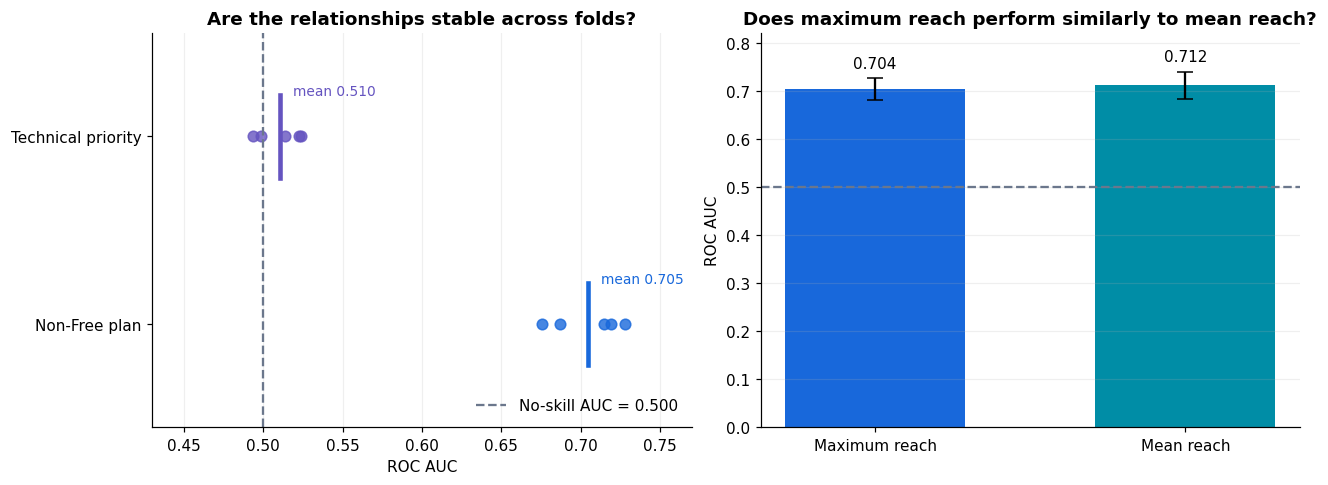

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.3), layout="constrained")
fold_plot = pd.concat([
    commercial_folds.assign(model="Non-Free plan"),
    priority_folds.assign(model="Technical priority"),
])
for index, (model_name, group) in enumerate(fold_plot.groupby("model", sort=False)):
    color = [BLUE, PURPLE][index]
    axes[0].scatter(group["auc"], np.full(len(group), index), color=color, s=48, alpha=.8)
    mean_auc = group["auc"].mean()
    axes[0].plot([mean_auc, mean_auc], [index - .22, index + .22], color=color, linewidth=3)
    axes[0].text(mean_auc + .008, index + .22, f"mean {mean_auc:.3f}", color=color, fontsize=9)
axes[0].axvline(.5, color=GREY, linestyle="--", linewidth=1.5, label="No-skill AUC = 0.500")
axes[0].set(
    title="Are the relationships stable across folds?", xlabel="ROC AUC",
    yticks=[0, 1], yticklabels=["Non-Free plan", "Technical priority"],
    xlim=(.43, .77), ylim=(-.55, 1.55),
)
axes[0].grid(axis="x", alpha=.2)
axes[0].legend(frameon=False, loc="lower right")

bars = axes[1].bar(
    ["Maximum reach", "Mean reach"], feature_sensitivity["AUC"],
    yerr=feature_sensitivity["fold AUC SD"], color=[BLUE, TEAL], capsize=5, width=.58,
)
axes[1].bar_label(bars, labels=[f"{value:.3f}" for value in feature_sensitivity["AUC"]], padding=5)
axes[1].axhline(.5, color=GREY, linestyle="--", linewidth=1.5)
axes[1].set(title="Does maximum reach perform similarly to mean reach?", ylabel="ROC AUC", ylim=(0, .82))
axes[1].grid(axis="y", alpha=.2)
save_show(fig, "06_model_validation.png")

In [7]:
commercial_auc = commercial_result["auc"]
priority_auc = priority_result["auc"]
commercial_gate = (
    "Collaboration has a usable association with the non-Free plan proxy."
    if commercial_auc >= .60 else "The commercial-concentration claim is not supported."
)
if priority_auc >= .60:
    priority_gate = "Existing priority already reflects collaboration enough to reject the blind-spot claim."
elif priority_auc <= .55:
    priority_gate = "Existing priority shows little ability to distinguish collaboration reach."
else:
    priority_gate = "The priority relationship is ambiguous."

display(Markdown(f'''**Observed:** the commercial-plan relationship reaches **{commercial_auc:.3f} AUC**
with fold SD **{commercial_result["fold_auc_sd"]:.3f}**. Existing priority reaches
**{priority_auc:.3f} grouped AUC** with fold SD **{priority_result["fold_auc_sd"]:.3f}**.

**Meaning:** {commercial_gate} {priority_gate}

**Limitation:** these retrospective models diagnose relationships. They do not forecast service outcomes,
assign the new queue or estimate revenue.'''))

**Observed:** the commercial-plan relationship reaches **0.704 AUC**
with fold SD **0.022**. Existing priority reaches
**0.509 grouped AUC** with fold SD **0.014**.

**Meaning:** Collaboration has a usable association with the non-Free plan proxy. Existing priority shows little ability to distinguish collaboration reach.

**Limitation:** these retrospective models diagnose relationships. They do not forecast service outcomes,
assign the new queue or estimate revenue.

## 5.4 Save Model Results for Downstream Stages

In [8]:
model_results = {
    "commercial_auc": float(commercial_auc),
    "commercial_fold_sd": float(commercial_result["fold_auc_sd"]),
    "priority_auc": float(priority_auc),
    "priority_fold_sd": float(priority_result["fold_auc_sd"]),
    "selected_C": float(selected_C),
    "selected_feature": selected_feature,
}
with open(ARTIFACTS / "model_results.json", "w") as f:
    json.dump(model_results, f, indent=2)
print("Saved: model_results.json -> ./artifacts/")
print(model_results)

Saved: model_results.json -> ./artifacts/
{'commercial_auc': 0.7037998836537485, 'commercial_fold_sd': 0.022326909377437264, 'priority_auc': 0.509362669452226, 'priority_fold_sd': 0.013763824201732385, 'selected_C': 1.0, 'selected_feature': 'max_collaborators'}
